
| |<font size="5">LinearRegression الانحدار الخطي البسيط    </font>|
|-:|-:|
|<img src="https://raw.githubusercontent.com/arvention/linear-regression/master/animation.gif" width=300></img>||
||<font size="4"> تحميل البيانات ومعالجتها </font>| 
||<font size="4"> Train, Test  تحديد بيانات التدريب والاختبار </font>| 
||<font size="4">Sklearn  توظيف خوارزمية من مكتبة </font>| 
||<font size="4"> training   تدريب البيانات </font>| 
||<font size="4"> Metrics   تقويم أداء الخوارزمية </font>| 


In [109]:
# dataset upload
import pandas as pd
import numpy as np
# df= pd.read_csv("../data/student_Mat.csv")
df= pd.read_csv("../data/Students_Grading_Dataset.csv")

In [110]:
# display max  columns
pd.set_option('display.max_columns', None)
df.head(3)

,Student_ID,First_Name,Last_Name,Email,Gender,Age,Department,Attendance (%),Midterm_Score,Final_Score,Assignments_Avg,Quizzes_Avg,Participation_Score,Projects_Score,Total_Score,Grade,Study_Hours_per_Week,Extracurricular_Activities,Internet_Access_at_Home,Parent_Education_Level,Family_Income_Level,Stress_Level (1-10),Sleep_Hours_per_Night
0,S1000,Omar,Williams,student0@university.com,Female,22,Engineering,52.29,55.03,57.82,84.22,74.06,3.99,85.90,56.09,F,6.2,No,Yes,High School,Medium,5,4.7
1,S1001,Maria,Brown,student1@university.com,Male,18,Engineering,97.27,97.23,45.80,NaN,94.24,8.32,55.65,50.64,A,19.0,No,Yes,NaN,Medium,4,9.0
2,S1002,Ahmed,Jones,student2@university.com,Male,24,Business,57.19,67.05,93.68,67.70,85.70,5.05,73.79,70.30,D,20.7,No,Yes,Master's,Low,6,6.2


In [111]:
df.dtypes

Student_ID                     object
First_Name                     object
Last_Name                      object
Email                          object
Gender                         object
Age                             int64
Department                     object
Attendance (%)                float64
Midterm_Score                 float64
Final_Score                   float64
Assignments_Avg               float64
Quizzes_Avg                   float64
Participation_Score           float64
Projects_Score                float64
Total_Score                   float64
Grade                          object
Study_Hours_per_Week          float64
Extracurricular_Activities     object
Internet_Access_at_Home        object
Parent_Education_Level         object
Family_Income_Level            object
Stress_Level (1-10)             int64
Sleep_Hours_per_Night         float64
dtype: object

In [112]:
(df.isna().sum()/df.shape[0]).sort_values(ascending=False)

Parent_Education_Level        0.3588
Assignments_Avg               0.1034
Attendance (%)                0.1032
Email                         0.0000
Student_ID                    0.0000
First_Name                    0.0000
Last_Name                     0.0000
Department                    0.0000
Age                           0.0000
Gender                        0.0000
Midterm_Score                 0.0000
Quizzes_Avg                   0.0000
Participation_Score           0.0000
Projects_Score                0.0000
Final_Score                   0.0000
Total_Score                   0.0000
Grade                         0.0000
Extracurricular_Activities    0.0000
Study_Hours_per_Week          0.0000
Internet_Access_at_Home       0.0000
Family_Income_Level           0.0000
Stress_Level (1-10)           0.0000
Sleep_Hours_per_Night         0.0000
dtype: float64

In [113]:
df[df.isna().any(axis=1)].head() # no missing values

,Student_ID,First_Name,Last_Name,Email,Gender,Age,Department,Attendance (%),Midterm_Score,Final_Score,Assignments_Avg,Quizzes_Avg,Participation_Score,Projects_Score,Total_Score,Grade,Study_Hours_per_Week,Extracurricular_Activities,Internet_Access_at_Home,Parent_Education_Level,Family_Income_Level,Stress_Level (1-10),Sleep_Hours_per_Night
1,S1001,Maria,Brown,student1@university.com,Male,18,Engineering,97.27,97.23,45.80,NaN,94.24,8.32,55.65,50.64,A,19.0,No,Yes,NaN,Medium,4,9.0
5,S1005,Liam,Brown,student5@university.com,Male,21,Engineering,NaN,78.85,43.53,71.40,52.20,6.38,67.29,62.08,B,8.5,Yes,Yes,PhD,High,1,5.0
6,S1006,Ahmed,Jones,student6@university.com,Male,24,Business,57.60,66.26,89.07,84.52,98.40,2.30,93.65,83.21,F,21.3,No,Yes,NaN,Low,5,6.4
7,S1007,Ahmed,Smith,student7@university.com,Male,19,Engineering,51.91,45.67,73.96,80.12,95.90,3.73,93.24,81.93,F,27.3,Yes,No,NaN,Medium,4,4.3
9,S1009,Sara,Smith,student9@university.com,Female,22,Engineering,64.01,87.96,98.47,96.98,55.63,5.88,78.60,84.99,A,9.6,No,Yes,NaN,Medium,10,6.4


In [114]:
df.dtypes

Student_ID                     object
First_Name                     object
Last_Name                      object
Email                          object
Gender                         object
Age                             int64
Department                     object
Attendance (%)                float64
Midterm_Score                 float64
Final_Score                   float64
Assignments_Avg               float64
Quizzes_Avg                   float64
Participation_Score           float64
Projects_Score                float64
Total_Score                   float64
Grade                          object
Study_Hours_per_Week          float64
Extracurricular_Activities     object
Internet_Access_at_Home        object
Parent_Education_Level         object
Family_Income_Level            object
Stress_Level (1-10)             int64
Sleep_Hours_per_Night         float64
dtype: object

In [115]:
# look for missing values 
df.isna().sum()/df.shape[0]

Student_ID                    0.0000
First_Name                    0.0000
Last_Name                     0.0000
Email                         0.0000
Gender                        0.0000
Age                           0.0000
Department                    0.0000
Attendance (%)                0.1032
Midterm_Score                 0.0000
Final_Score                   0.0000
Assignments_Avg               0.1034
Quizzes_Avg                   0.0000
Participation_Score           0.0000
Projects_Score                0.0000
Total_Score                   0.0000
Grade                         0.0000
Study_Hours_per_Week          0.0000
Extracurricular_Activities    0.0000
Internet_Access_at_Home       0.0000
Parent_Education_Level        0.3588
Family_Income_Level           0.0000
Stress_Level (1-10)           0.0000
Sleep_Hours_per_Night         0.0000
dtype: float64

In [116]:
df["Assignments_Avg"].describe().T[["mean", "max"]]

mean    74.798673
max     99.980000
Name: Assignments_Avg, dtype: float64

In [117]:
# use simpel imputer to fill missing values with mean  value
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean')
df["Assignments_Avg"] = imputer.fit_transform(df[["Assignments_Avg"]]) 
df["Attendance (%)"] = imputer.fit_transform(df[["Attendance (%)"]]) 


In [118]:
# selec numerical features only 
num_features = df.select_dtypes(exclude="object").columns
df_num = df[num_features]

In [119]:
X = df_num.drop("Final_Score", axis=1) 
y = df['Final_Score']

In [120]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [121]:
X_train.isna().sum()

Age                      0
Attendance (%)           0
Midterm_Score            0
Assignments_Avg          0
Quizzes_Avg              0
Participation_Score      0
Projects_Score           0
Total_Score              0
Study_Hours_per_Week     0
Stress_Level (1-10)      0
Sleep_Hours_per_Night    0
dtype: int64

In [122]:
# Standardize the features (ElasticNet works better with standardized data)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## SelectBest 

In [123]:
# import selectKbest
from sklearn.feature_selection import SelectKBest, f_regression
selector = SelectKBest(score_func=f_regression, k=k)
X_train_selected = selector.fit_transform(X_train, y_train)


In [124]:
# Get the selected feature names
selected_features = X.columns[selector.get_support()]

In [125]:
# Display the selected features and their scores
feature_scores = pd.DataFrame({
    'Feature': X.columns,
    'Score': selector.scores_
}).sort_values(by='Score', ascending=False)

print("Selected Features:")
print(selected_features)
print("\nFeature Scores:")
print(feature_scores)

Selected Features:
Index(['Age', 'Attendance (%)', 'Assignments_Avg', 'Participation_Score',
       'Sleep_Hours_per_Night'],
      dtype='object')

Feature Scores:
                  Feature     Score
1          Attendance (%)  3.703826
5     Participation_Score  1.966279
0                     Age  1.200658
10  Sleep_Hours_per_Night  1.035096
3         Assignments_Avg  0.817878
7             Total_Score  0.786475
8    Study_Hours_per_Week  0.275232
2           Midterm_Score  0.233786
4             Quizzes_Avg  0.165736
6          Projects_Score  0.163867
9     Stress_Level (1-10)  0.158332


## ElasticsNet

In [126]:
# Train the ElasticNet model
from sklearn.linear_model import ElasticNet

elastic_net = ElasticNet(alpha=1.0, l1_ratio=0.5, random_state=42)  # Adjust alpha and l1_ratio as needed
elastic_net.fit(X_train_scaled, y_train)

ElasticNet(random_state=42)

In [127]:
# Get feature importance (coefficients)
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': elastic_net.coef_
})

In [128]:
# Filter out features with zero coefficients (not selected by ElasticNet)
selected_features = feature_importance[feature_importance['Coefficient'] != 0]


In [129]:
# Sort features by absolute coefficient value
selected_features['Absolute_Coefficient'] = selected_features['Coefficient'].abs()
selected_features = selected_features.sort_values(by='Absolute_Coefficient', ascending=False)


/tmp/ipykernel_23093/1881345791.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_features['Absolute_Coefficient'] = selected_features['Coefficient'].abs()


In [130]:

# Display the selected features with the most impact
print(selected_features[['Feature', 'Coefficient']])

          Feature  Coefficient
1  Attendance (%)    -0.017058


In [ ]:
# Use SelectKBest with an F-test for regression
from sklearn.feature_selection import SelectKBest, f_regression

k = 5  # Number of top features to select
selector = SelectKBest(score_func=f_regression, k=k)
X_train_selected = selector.fit_transform(X_train, y_train)

![](https://image.flaticon.com/icons/png/128/3079/3079166.png)

###  Modelization

-  her we ll take only frist 3 important features contributing teh most to the final score
-  1          Attendance (%)  3.703826
-  5     Participation_Score  1.966279
-  0                     Age  1.200658
-  10  Sleep_Hours_per_Night  1.035096

In [132]:
# Example: Select specific features and the target

# Select numerical columns
sel_features = ['Attendance (%)', 'Participation_Score', 'Age', 'Sleep_Hours_per_Night']
X = df[sel_features]
y = df['Final_Score'] # target

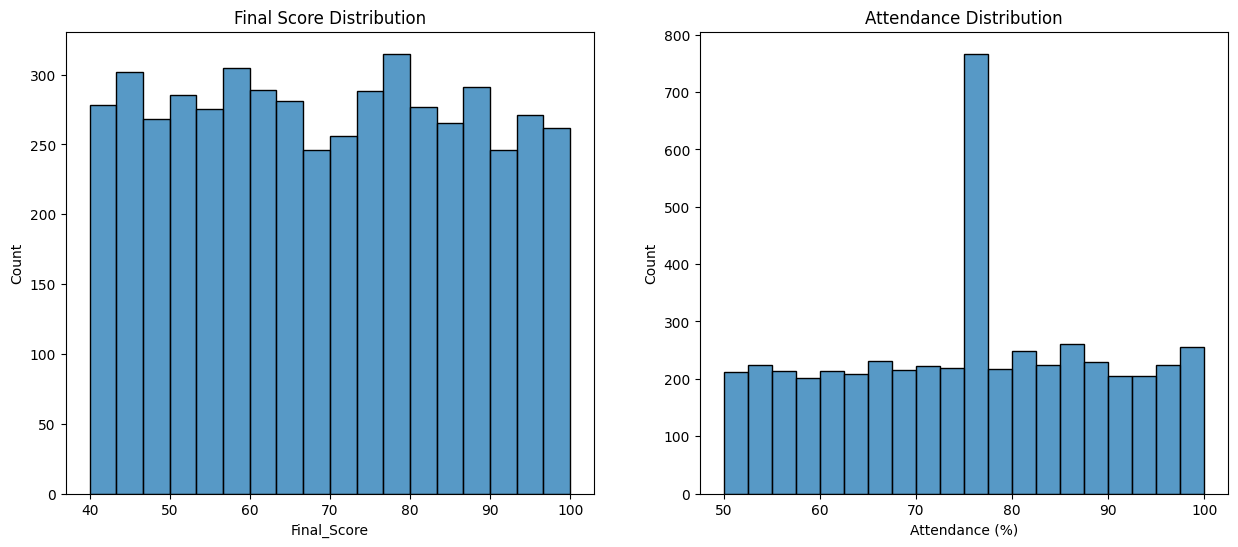

In [133]:
# plot the distribution of the final score and the attendance
import seaborn as sns
import matplotlib.pyplot as plt
# plot two graphes next to each others 
fig, ax = plt.subplots(1, 2, figsize=(15, 6))
# plot the first graph
sns.histplot(df.Final_Score, ax=ax[0])
ax[0].set_title('Final Score Distribution')
# plot the second graph
sns.histplot(df['Attendance (%)'], ax=ax[1])
ax[1].set_title('Attendance Distribution')
plt.show()

In [134]:
# dieplay shapiro test for normality for all sel_features attribes as well as the target final_score 
from scipy.stats import shapiro
for col in sel_features + ['Final_Score']:
    stat, p = shapiro(df[col])
    print(f'{col}: p-value = {p:.4f}')

Attendance (%): p-value = 0.0000
Participation_Score: p-value = 0.0000
Age: p-value = 0.0000
Sleep_Hours_per_Night: p-value = 0.0000
Final_Score: p-value = 0.0000


In [135]:
from scipy.stats import boxcox

# Apply Box-Cox transformation (ensure no zero or negative values)
df["Normalized_file_Score"], _ = boxcox(df["Final_Score"] + 1)  # Add 1 to avoid zero values

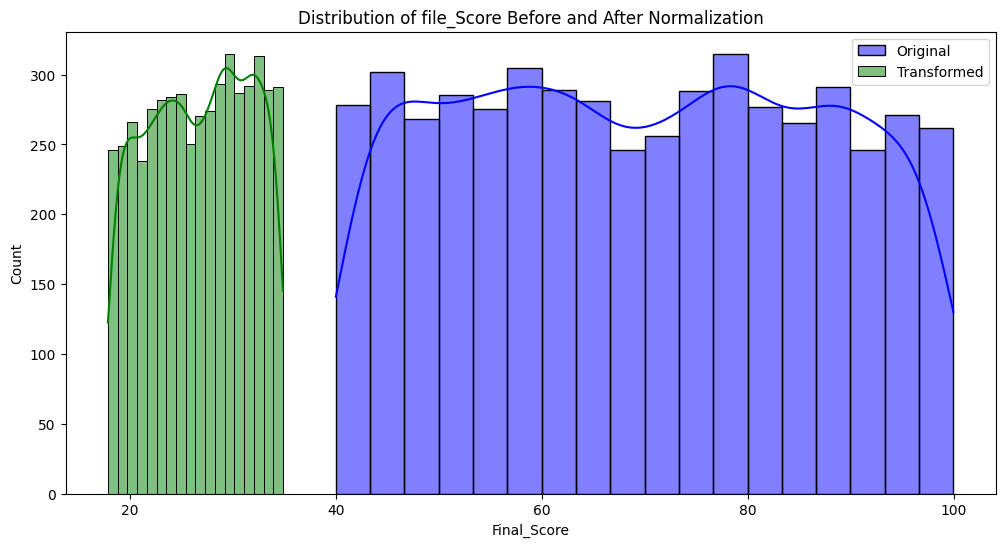

In [136]:
# Plot the original and transformed distributions
plt.figure(figsize=(12, 6))
sns.histplot(df["Final_Score"], kde=True, color="blue", label="Original")
sns.histplot(df["Normalized_file_Score"], kde=True, color="green", label="Transformed")
plt.legend()
plt.title("Distribution of file_Score Before and After Normalization")
plt.show()

In [137]:
# apply boxcox for all sel_features attribes
for col in sel_features:
    df[f'Normalized_{col}'], _ = boxcox(df[col] + 1)  # Add

 standard score   :
$\large  z= \frac{x-\mu}{\sigma}$

![](https://i.ibb.co/QChD6Y4/Train-test-1.jpg)

In [138]:
# split the data into train and test
from sklearn.model_selection import train_test_split 
X_train, X_test, y_train, y_test=train_test_split(X, y  ,test_size=.3, random_state=42)

![](https://static.thenounproject.com/png/2010152-200.png)

In [139]:
# linear regression model
from sklearn.linear_model import LinearRegression
lreg=LinearRegression()

In [140]:
# traning the model
lreg.fit(X_train, y_train)

LinearRegression()

In [141]:
# PRedcition 
y_pred=lreg.predict(X_test)

![](https://i.ibb.co/wQC2qF6/ruler.png)

In [142]:
# display the X_test, y_test  score 
print(f" Score  : {lreg.score(X_test, y_test):.3f}")

 Score  : -0.002


In [143]:
#  Mertrics  
from sklearn import metrics
import numpy as np
print(f" MAE  : {metrics.mean_absolute_error(y_test, y_pred):.3f}")
print(f" MSE  : {metrics.mean_squared_error(y_test, y_pred):.3f}")
print(f" MSE  : {metrics.mean_squared_error(y_test, y_pred):.3f}")

print(f" R2  : {metrics.r2_score(y_test, y_pred):.3f}")


 MAE  : 14.809
 MSE  : 290.197
 MSE  : 290.197
 R2  : -0.002


In [144]:
lreg.coef_ , lreg.intercept_

(array([-0.03430746,  0.12965391, -0.24145475, -0.22715444]),
 np.float64(78.11477974329617))

In [145]:
y_test.shape, y_test.shape

((1500,), (1500,))

In [147]:
# Flatten the arrays

# Create the DataFrame
df_pred = pd.DataFrame({"Actual_P": y_test, "Predicted_P": y_pred})
df_pred.head()

,Actual_P,Predicted_P
1501,44.10,67.837393
2586,83.07,69.321784
2653,81.60,68.679625
1055,44.83,69.616518
705,82.38,68.894762


Text(0.5, 1.0, 'Actual vs Predicted Final Score')

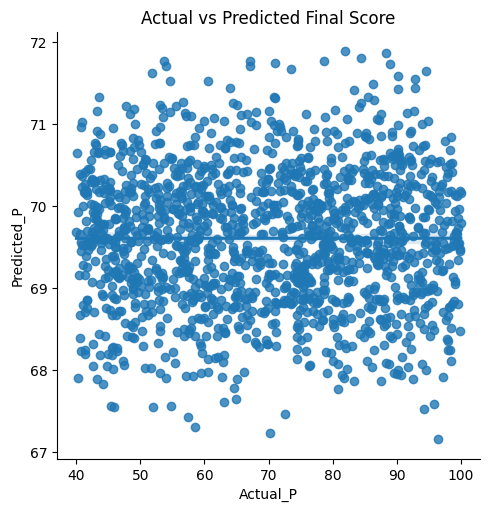

In [155]:

# use seaborn sns  lmplot tp  plot the actual and predicted values of dataframe df_pred
_= sns.lmplot(x="Actual_P",  y= "Predicted_P", data=df_pred)
plt.title("Actual vs Predicted Final Score")

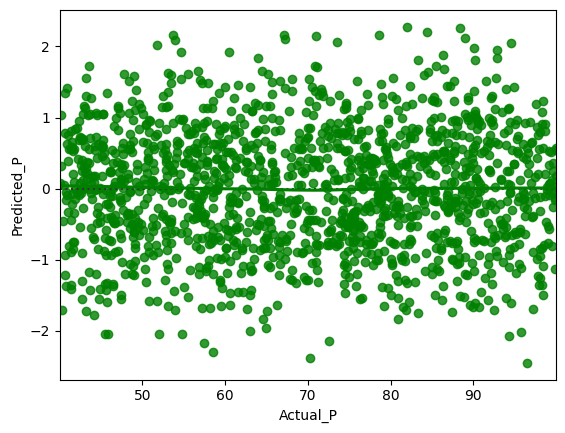

In [159]:
#. residual plot
_=sns.residplot(x= df_pred.Actual_P, y=df_pred.Predicted_P, lowess=True, color="g")

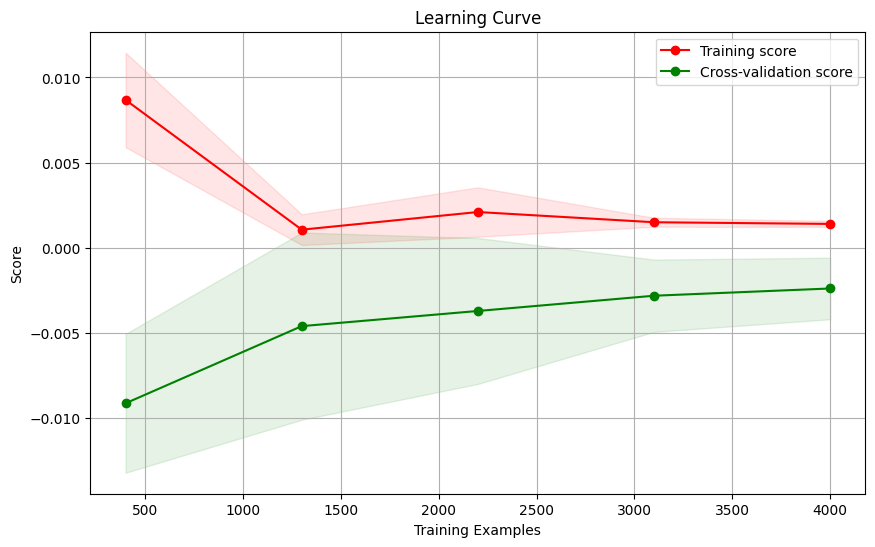

In [160]:
# how display  trainin curve vs testing curve
from sklearn.model_selection import learning_curve
train_sizes, train_scores, test_scores = learning_curve(lreg, X, y, cv=5)
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std, alpha=0.1, color="r")
plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                    test_scores_mean + test_scores_std, alpha=0.1, color="g")
plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score")
plt.title("Learning Curve")
plt.xlabel("Training Examples")
plt.ylabel("Score")
plt.grid()
plt.legend()
plt.show()
